In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

results_dir = Path(".")
shortcuts_path = results_dir / ".." / ".." / "src" / "0_data_processing" / "leipzig" / "lepzig_shortcuts.csv"

# load language code -> full name mapping
shortcuts = pd.read_csv(shortcuts_path)
code_to_lang = dict(zip(shortcuts["code"], shortcuts["language"]))

# load all result files
seg_true = pd.read_csv(results_dir / "result_segment_true.csv")
seg_univ = pd.read_csv(results_dir / "result_segment_universal.csv")
root_true = pd.read_csv(results_dir / "result_root_true.csv")
root_univ = pd.read_csv(results_dir / "result_root_universal.csv")

# add full language names
for df in [seg_true, seg_univ, root_true, root_univ]:
    df["language"] = df["lang"].map(code_to_lang).fillna(df["lang"])

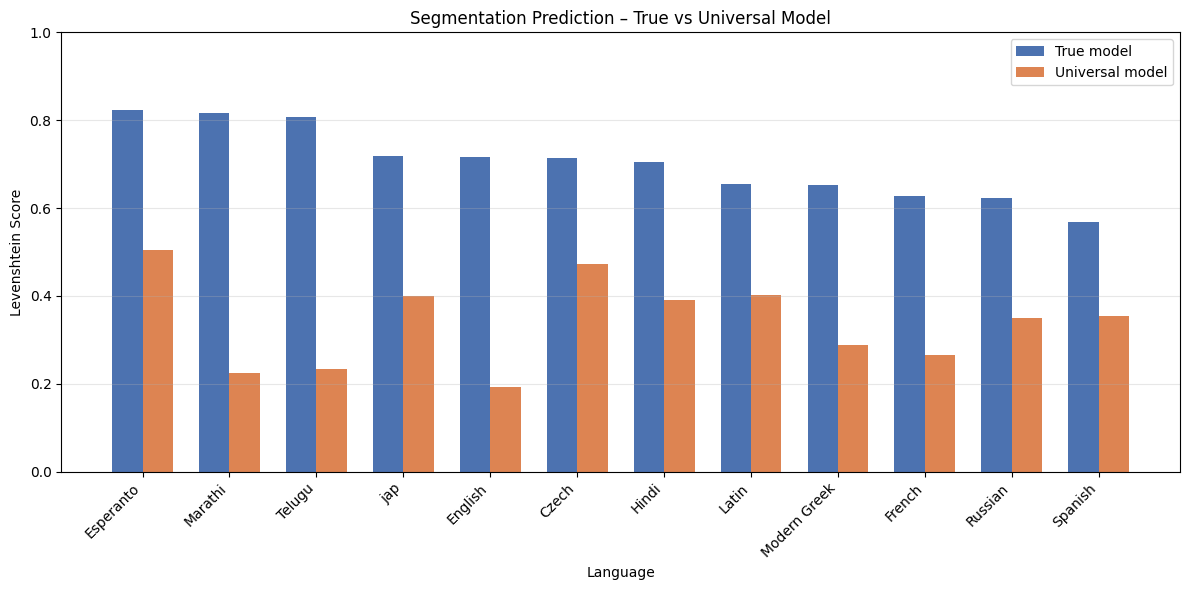

In [8]:
# --- Segmentation: True vs Universal ---
# Sort by true model's levenshtein_score descending
seg_true_sorted = seg_true.sort_values("levenshtein_score", ascending=False)
order = seg_true_sorted["language"].tolist()
seg_univ_sorted = seg_univ.set_index("language").loc[order].reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(order))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], seg_true_sorted["levenshtein_score"].values, width,
               label="True model", color="#4C72B0")
bars2 = ax.bar([i + width/2 for i in x], seg_univ_sorted["levenshtein_score"].values, width,
               label="Universal model", color="#DD8452")

ax.set_xlabel("Language")
ax.set_ylabel("Levenshtein Score")
ax.set_title("Segmentation Prediction – True vs Universal Model")
ax.set_xticks(list(x))
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

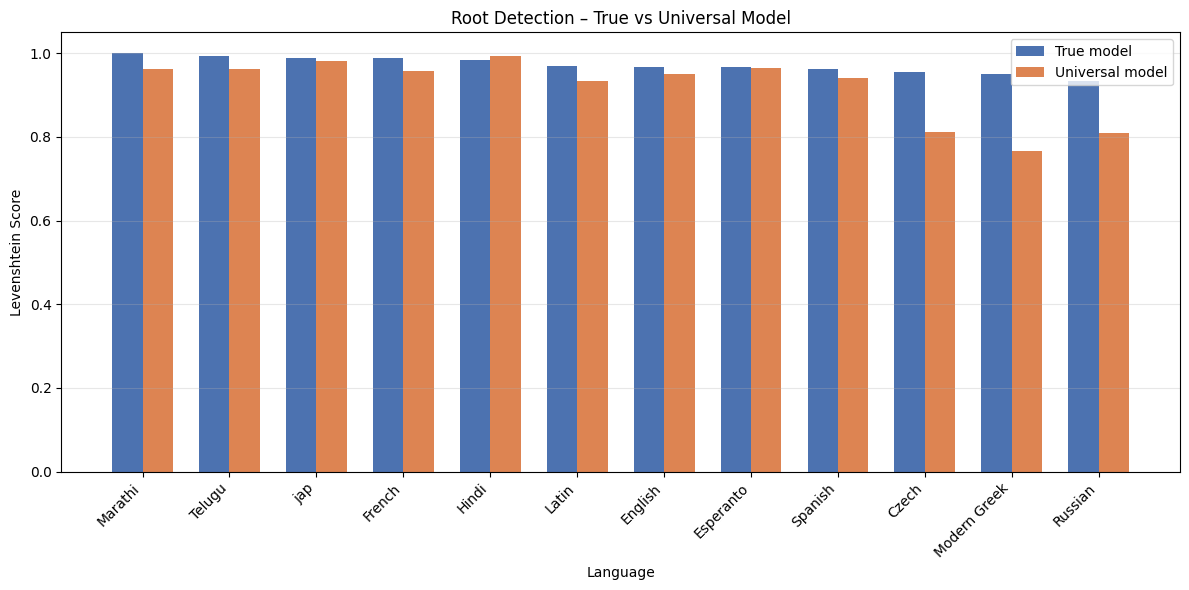

In [9]:
# --- Root Detection: True vs Universal ---
# Sort by true model's levenshtein_score descending
root_true_sorted = root_true.sort_values("levenshtein_score", ascending=False)
order_root = root_true_sorted["language"].tolist()
root_univ_sorted = root_univ.set_index("language").loc[order_root].reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(order_root))

bars1 = ax.bar([i - width/2 for i in x], root_true_sorted["levenshtein_score"].values, width,
               label="True model", color="#4C72B0")
bars2 = ax.bar([i + width/2 for i in x], root_univ_sorted["levenshtein_score"].values, width,
               label="Universal model", color="#DD8452")

ax.set_xlabel("Language")
ax.set_ylabel("Levenshtein Score")
ax.set_title("Root Detection – True vs Universal Model")
ax.set_xticks(list(x))
ax.set_xticklabels(order_root, rotation=45, ha="right")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()